# San Francisco Salaries

In [2]:
import pandas as pd

### Erstelle aus salaries.csv einen DataFrame

In [ ]:
sal = pd.read_csv("./salaries.csv", low_memory=False, na_values=['Not Provided'])

for col in ['BasePay','OvertimePay','OtherPay','Benefits','TotalPay','TotalPayBenefits']:
    sal[col] = pd.to_numeric(sal[col], errors='coerce')
sal['Year'] = pd.to_numeric(sal['Year'], errors='coerce')

sal.shape


(148654, 13)

** Empfohlen: `head()` **

In [4]:
# Empfohlen: head()
sal.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


### Wie viele Observations gibt es?

In [5]:
# Wie viele Observations gibt es?
sal.shape[0]

148654

### Was ist das arithmetische Mittel von `BasePay`?
Lösung: `66325.44884050643`

In [6]:
# Arithmetisches Mittel von BasePay
sal['BasePay'].mean()

np.float64(66325.44884048769)

### Was ist der höchste Geldbetrag, der als `OvertimePay` vorhanden ist?
Lösung: `245131.88`

In [7]:
# Höchster Betrag in OvertimePay
sal['OvertimePay'].max()

245131.88

### Welchen Job hat JOSEPH DRISCOLL? (**Nicht** Joseph Driscoll).
Lösung:
```
CAPTAIN, FIRE SUPPRESSION
```

In [8]:
# Welchen Job hat JOSEPH DRISCOLL? (Großschreibung wie im Datensatz)
sal.loc[sal['EmployeeName']=='JOSEPH DRISCOLL', 'JobTitle'].iloc[0]

'CAPTAIN, FIRE SUPPRESSION'

### Was ist das Gesamtgehalt von JOSEPH DRISCOLL?
Lösung:
```
270324.91
```

In [9]:
# Gesamtgehalt von JOSEPH DRISCOLL (TotalPay)
sal.loc[sal['EmployeeName']=='JOSEPH DRISCOLL', 'TotalPay'].iloc[0]

np.float64(270324.91)

### Wie lautet der Name der bestverdienensten Person?
Lösung: `NATHANIEL FORD`

In [10]:
# Name der bestverdienensten Person (nach TotalPayBenefits)
sal.loc[sal['TotalPayBenefits'].idxmax(), 'EmployeeName']

'NATHANIEL FORD'

### Wie lautet der Name der am schlechtest bezahlten Person?
Lösung: `Joe Lopez`

In [11]:
# Name der am schlechtest bezahlten Person (nach TotalPayBenefits)
sal.loc[sal['TotalPayBenefits'].idxmin(), 'EmployeeName']

'Joe Lopez'

### Ermittle für die Jahre 2012-2014 den arithmetischen Mittelwert des `BasePay`s aller Personen.
Lösung:
```
Year
2012    65436.406857
2013    69630.030216
2014    66564.421924
```


In [12]:
# Arithmetisches Mittel des BasePay für die Jahre 2012-2014
sal.groupby('Year')['BasePay'].mean().loc[[2012,2013,2014]]

Year
2012    65436.406857
2013    69630.030216
2014    66564.421924
Name: BasePay, dtype: float64

### Wie viele unterschiedliche Jobs gibt es?
Lösung: `2159`

In [13]:
# Wie viele unterschiedliche Jobs gibt es?
sal['JobTitle'].nunique()

2159

### Welche sind die Top 5 häufigsten Jobs und wie viele gibt es davon jeweils?
Lösung:
```
Transit Operator                7036
Special Nurse                   4389
Registered Nurse                3736
Public Svc Aide-Public Works    2518
Police Officer 3                2421
Name: JobTitle, dtype: int64
```


In [14]:
# Top 5 häufigsten Jobs und Anzahl
sal['JobTitle'].value_counts().head(5)

JobTitle
Transit Operator                7036
Special Nurse                   4389
Registered Nurse                3736
Public Svc Aide-Public Works    2518
Police Officer 3                2421
Name: count, dtype: int64

### Wie viele Jobs gibt es, die 2013 nur eine Person ausübte?
Lösung: `202`

In [15]:
# Wie viele Jobs gab es 2013, die nur eine Person ausübte?
counts_2013 = sal[sal['Year']==2013]['JobTitle'].value_counts()
(counts_2013==1).sum()

np.int64(202)

### Wie viele Personen haben `'chief'` (caseinsensitive) im Jobnamen?
Lösung: `627`

In [16]:
# Wie viele Personen haben 'chief' (case-insensitive) im Jobnamen?
sal['JobTitle'].str.contains('chief', case=False, na=False).sum()

np.int64(627)

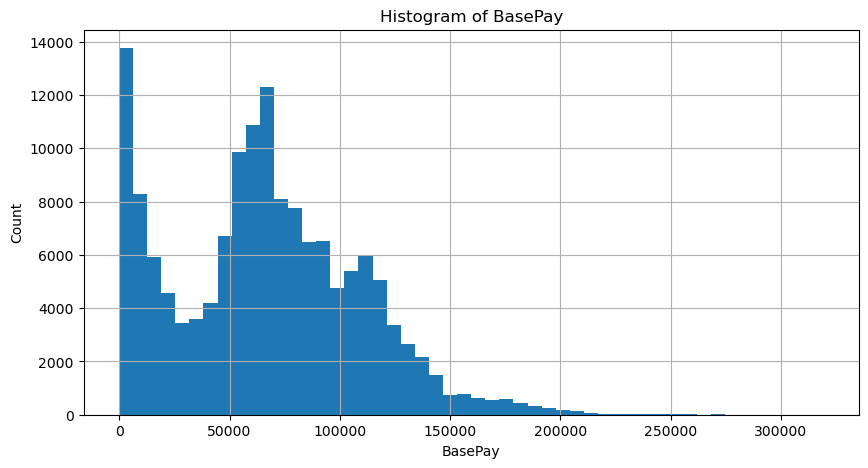

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
# Histogramm des BasePay (nur gültige Werte)
plt.figure(figsize=(10,5))
sal['BasePay'].dropna().hist(bins=50)
plt.title('Histogram of BasePay')
plt.xlabel('BasePay')
plt.ylabel('Count')
plt.show()